# Task 9: Anchor-Free Object Detection (YOLOv8-style) Loss Backpropagation

**Objective:** Architect a multi-task object localization loss module that simultaneously tracks bounding-box regression (via Complete IoU) and classification, with dynamic label assignment between targets and anchor-free grid predictions.

**Tech stack:** PyTorch, NumPy, Matplotlib (OpenCV is used only for a simple visualization helper; if unavailable we fall back to Matplotlib patches).


In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## 1. Anchor-free grid setup

Following YOLOv8, every feature-map cell directly regresses 4 box offsets (left, top, right, bottom distances to the cell center) plus per-class logits. No predefined anchor boxes are used.

In [2]:

IMG_SIZE = 64
STRIDE = 8
GRID = IMG_SIZE // STRIDE  # 8x8 grid
NUM_CLASSES = 3

# Precompute grid cell centers (in image coordinates)
ys, xs = torch.meshgrid(torch.arange(GRID), torch.arange(GRID), indexing='ij')
grid_centers = torch.stack([(xs + 0.5) * STRIDE, (ys + 0.5) * STRIDE], dim=-1).view(-1, 2).float()  # (GRID*GRID, 2) -> (cx, cy)
grid_centers.shape


torch.Size([64, 2])

## 2. Complete IoU (CIoU) loss

CIoU extends IoU with a penalty term for the normalized distance between box centers and a consistency term for aspect ratio, giving smoother gradients than plain IoU, especially for non-overlapping boxes.

In [3]:

def box_ltrb_to_xyxy(centers, ltrb):
    # centers: (N,2) cx,cy   ltrb: (N,4) l,t,r,b distances
    l, t, r, b = ltrb.unbind(-1)
    cx, cy = centers.unbind(-1)
    x1 = cx - l
    y1 = cy - t
    x2 = cx + r
    y2 = cy + b
    return torch.stack([x1, y1, x2, y2], dim=-1)


def ciou_loss(pred_xyxy, target_xyxy, eps=1e-7):
    px1, py1, px2, py2 = pred_xyxy.unbind(-1)
    tx1, ty1, tx2, ty2 = target_xyxy.unbind(-1)

    # intersection
    ix1 = torch.max(px1, tx1); iy1 = torch.max(py1, ty1)
    ix2 = torch.min(px2, tx2); iy2 = torch.min(py2, ty2)
    inter_w = (ix2 - ix1).clamp(min=0)
    inter_h = (iy2 - iy1).clamp(min=0)
    inter = inter_w * inter_h

    p_area = (px2 - px1).clamp(min=0) * (py2 - py1).clamp(min=0)
    t_area = (tx2 - tx1).clamp(min=0) * (ty2 - ty1).clamp(min=0)
    union = p_area + t_area - inter + eps
    iou = inter / union

    # smallest enclosing box
    cx1 = torch.min(px1, tx1); cy1 = torch.min(py1, ty1)
    cx2 = torch.max(px2, tx2); cy2 = torch.max(py2, ty2)
    c_diag = (cx2 - cx1) ** 2 + (cy2 - cy1) ** 2 + eps

    p_cx = (px1 + px2) / 2; p_cy = (py1 + py2) / 2
    t_cx = (tx1 + tx2) / 2; t_cy = (ty1 + ty2) / 2
    center_dist = (p_cx - t_cx) ** 2 + (p_cy - t_cy) ** 2

    p_w = (px2 - px1).clamp(min=eps); p_h = (py2 - py1).clamp(min=eps)
    t_w = (tx2 - tx1).clamp(min=eps); t_h = (ty2 - ty1).clamp(min=eps)
    v = (4 / (np.pi ** 2)) * (torch.atan(t_w / t_h) - torch.atan(p_w / p_h)) ** 2
    with torch.no_grad():
        alpha = v / (1 - iou + v + eps)

    ciou = iou - center_dist / c_diag - alpha * v
    return 1 - ciou  # loss, elementwise


## 3. Synthetic detection dataset

Each image contains 1-3 axis-aligned boxes with a class id. We build a `Dataset` that returns the image and a variable-length list of `(class, x1,y1,x2,y2)` targets.

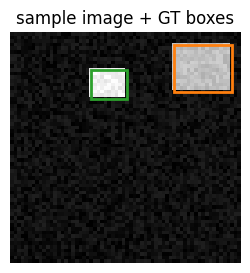

In [4]:

class DetectionDataset(torch.utils.data.Dataset):
    def __init__(self, n_samples=200, img_size=IMG_SIZE, max_objects=3, num_classes=NUM_CLASSES):
        self.n = n_samples
        self.img_size = img_size
        self.max_objects = max_objects
        self.num_classes = num_classes

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        s = self.img_size
        img = np.random.rand(s, s).astype(np.float32) * 0.1
        n_obj = np.random.randint(1, self.max_objects + 1)
        boxes, labels = [], []
        for _ in range(n_obj):
            w = np.random.randint(8, 20)
            h = np.random.randint(8, 20)
            x1 = np.random.randint(0, s - w)
            y1 = np.random.randint(0, s - h)
            x2, y2 = x1 + w, y1 + h
            cls = np.random.randint(0, self.num_classes)
            img[y1:y2, x1:x2] += 0.4 + 0.15 * cls
            boxes.append([x1, y1, x2, y2])
            labels.append(cls)
        img = np.clip(img, 0, 1)
        return (torch.from_numpy(img).unsqueeze(0).float(),
                torch.tensor(boxes, dtype=torch.float32),
                torch.tensor(labels, dtype=torch.long))


def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch])
    boxes = [b[1] for b in batch]
    labels = [b[2] for b in batch]
    return imgs, boxes, labels

train_ds = DetectionDataset(n_samples=128)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)

img, boxes, labels = train_ds[0]
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(img[0], cmap='gray')
for (x1,y1,x2,y2), c in zip(boxes.tolist(), labels.tolist()):
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=f'C{c}', linewidth=2))
ax.set_title('sample image + GT boxes'); ax.axis('off')
plt.show()


## 4. Anchor-free prediction head

In [5]:

class TinyBackbone(nn.Module):
    def __init__(self, base=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base, 3, padding=1), nn.BatchNorm2d(base), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(base, base*2, 3, padding=1), nn.BatchNorm2d(base*2), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(base*2, base*4, 3, padding=1), nn.BatchNorm2d(base*4), nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.net(x)  # (B, base*4, GRID, GRID)


class DetectionHead(nn.Module):
    def __init__(self, in_ch, num_classes):
        super().__init__()
        self.reg = nn.Conv2d(in_ch, 4, 1)  # l,t,r,b (raw, passed through softplus for positivity)
        self.cls = nn.Conv2d(in_ch, num_classes, 1)

    def forward(self, feat):
        ltrb = F.softplus(self.reg(feat))  # ensure positive distances
        cls_logits = self.cls(feat)
        return ltrb, cls_logits


class AnchorFreeDetector(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, base=16):
        super().__init__()
        self.backbone = TinyBackbone(base)
        self.head = DetectionHead(base*4, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        ltrb, cls_logits = self.head(feat)  # (B,4,G,G), (B,C,G,G)
        return ltrb, cls_logits

model = AnchorFreeDetector().to(device)
sum(p.numel() for p in model.parameters())


23975

## 5. Dynamic target assignment

For each ground-truth box we assign it to every grid cell whose center falls **inside** the box (a simplified version of YOLOv8's task-aligned assignment). Cells with no assigned object are trained as background for the classification branch and excluded from the regression loss.

In [6]:

def assign_targets(boxes, labels, grid_centers, num_classes):
    """boxes: (N,4) xyxy in image coords, labels: (N,)
    Returns: reg_targets (G*G,4) ltrb, cls_targets (G*G,) with -1 for background,
             pos_mask (G*G,) bool
    """
    n_cells = grid_centers.size(0)
    reg_targets = torch.zeros(n_cells, 4)
    cls_targets = torch.full((n_cells,), -1, dtype=torch.long)
    pos_mask = torch.zeros(n_cells, dtype=torch.bool)

    if boxes.numel() == 0:
        return reg_targets, cls_targets, pos_mask

    for box, cls in zip(boxes, labels):
        x1, y1, x2, y2 = box
        cx, cy = grid_centers[:, 0], grid_centers[:, 1]
        inside = (cx >= x1) & (cx <= x2) & (cy >= y1) & (cy <= y2)
        if inside.sum() == 0:
            # fall back: assign the single nearest cell to guarantee supervision
            dists = (cx - (x1+x2)/2)**2 + (cy - (y1+y2)/2)**2
            inside = torch.zeros_like(inside)
            inside[dists.argmin()] = True
        l = (cx[inside] - x1)
        t = (cy[inside] - y1)
        r = (x2 - cx[inside])
        b = (y2 - cy[inside])
        reg_targets[inside] = torch.stack([l, t, r, b], dim=-1)
        cls_targets[inside] = cls.item()
        pos_mask |= inside
    return reg_targets, cls_targets, pos_mask


## 6. Combined detection loss (CIoU regression + classification)

In [7]:

def detection_loss(ltrb_pred, cls_pred, boxes_list, labels_list, grid_centers, num_classes):
    B = ltrb_pred.size(0)
    ltrb_pred_flat = ltrb_pred.permute(0, 2, 3, 1).reshape(B, -1, 4)       # (B, G*G, 4)
    cls_pred_flat = cls_pred.permute(0, 2, 3, 1).reshape(B, -1, num_classes)  # (B, G*G, C)

    total_reg_loss = 0.0
    total_cls_loss = 0.0
    n_pos_total = 0

    for i in range(B):
        reg_t, cls_t, pos_mask = assign_targets(boxes_list[i], labels_list[i], grid_centers, num_classes)
        reg_t, cls_t, pos_mask = reg_t.to(ltrb_pred.device), cls_t.to(ltrb_pred.device), pos_mask.to(ltrb_pred.device)

        # classification: background cells get a 'no-object' target handled via one-vs-all BCE
        cls_target_onehot = torch.zeros(cls_pred_flat.size(1), num_classes, device=ltrb_pred.device)
        if pos_mask.any():
            cls_target_onehot[pos_mask] = F.one_hot(cls_t[pos_mask], num_classes).float()
        cls_loss = F.binary_cross_entropy_with_logits(cls_pred_flat[i], cls_target_onehot, reduction='mean')
        total_cls_loss += cls_loss

        if pos_mask.any():
            pred_xyxy = box_ltrb_to_xyxy(grid_centers.to(ltrb_pred.device)[pos_mask], ltrb_pred_flat[i][pos_mask])
            target_xyxy = box_ltrb_to_xyxy(grid_centers.to(ltrb_pred.device)[pos_mask], reg_t[pos_mask])
            reg_loss = ciou_loss(pred_xyxy, target_xyxy).mean()
            total_reg_loss += reg_loss
            n_pos_total += pos_mask.sum().item()

    total_reg_loss = total_reg_loss / max(B, 1)
    total_cls_loss = total_cls_loss / max(B, 1)
    loss = total_reg_loss + total_cls_loss
    return loss, total_reg_loss.item() if torch.is_tensor(total_reg_loss) else total_reg_loss, total_cls_loss.item()


## 7. Training loop

In [8]:

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 15
gc = grid_centers.to(device)
history = {'loss': [], 'reg': [], 'cls': []}

for epoch in range(epochs):
    model.train()
    ep_loss = ep_reg = ep_cls = 0.0
    for imgs, boxes_list, labels_list in train_loader:
        imgs = imgs.to(device)
        ltrb_pred, cls_pred = model(imgs)
        loss, reg_l, cls_l = detection_loss(ltrb_pred, cls_pred, boxes_list, labels_list, gc, NUM_CLASSES)
        opt.zero_grad()
        loss.backward()
        opt.step()
        ep_loss += loss.item(); ep_reg += reg_l; ep_cls += cls_l
    nb_ = len(train_loader)
    history['loss'].append(ep_loss/nb_); history['reg'].append(ep_reg/nb_); history['cls'].append(ep_cls/nb_)
    print(f"epoch {epoch+1}/{epochs} loss={ep_loss/nb_:.4f} ciou_reg={ep_reg/nb_:.4f} cls={ep_cls/nb_:.4f}")


epoch 1/15 loss=1.4889 ciou_reg=0.8716 cls=0.6173


epoch 2/15 loss=0.9964 ciou_reg=0.6270 cls=0.3694


epoch 3/15 loss=0.7577 ciou_reg=0.5087 cls=0.2491


epoch 4/15 loss=0.6159 ciou_reg=0.4253 cls=0.1906


epoch 5/15 loss=0.5475 ciou_reg=0.4021 cls=0.1454


...

epoch 11/15 loss=0.3670 ciou_reg=0.2869 cls=0.0802


epoch 12/15 loss=0.3638 ciou_reg=0.2809 cls=0.0829


epoch 13/15 loss=0.3622 ciou_reg=0.2813 cls=0.0809


epoch 14/15 loss=0.3474 ciou_reg=0.2733 cls=0.0742


epoch 15/15 loss=0.3212 ciou_reg=0.2523 cls=0.0689


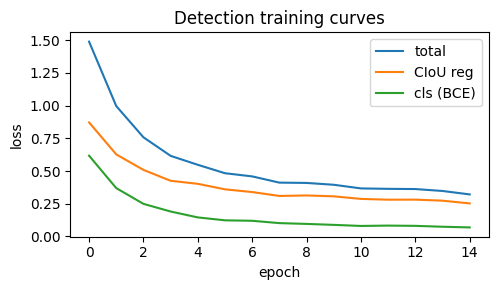

In [9]:

plt.figure(figsize=(5,3))
plt.plot(history['loss'], label='total')
plt.plot(history['reg'], label='CIoU reg')
plt.plot(history['cls'], label='cls (BCE)')
plt.legend(); plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Detection training curves')
plt.tight_layout(); plt.show()


## 8. Qualitative inference check

We threshold classification confidence and decode the top predicted boxes back to image coordinates for a validation sample.

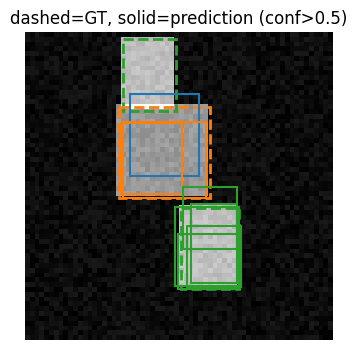

8 cells fired above 0.5 confidence


In [10]:

model.eval()
img, gt_boxes, gt_labels = train_ds[1]
with torch.no_grad():
    ltrb_pred, cls_pred = model(img.unsqueeze(0).to(device))
    ltrb_pred = ltrb_pred.permute(0,2,3,1).reshape(-1,4).cpu()
    cls_prob = torch.sigmoid(cls_pred).permute(0,2,3,1).reshape(-1, NUM_CLASSES).cpu()

conf, cls_idx = cls_prob.max(dim=1)
keep = conf > 0.5
pred_boxes = box_ltrb_to_xyxy(grid_centers[keep], ltrb_pred[keep])

fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(img[0], cmap='gray')
for (x1,y1,x2,y2), c in zip(gt_boxes.tolist(), gt_labels.tolist()):
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=f'C{c}', linewidth=2, linestyle='--'))
for (x1,y1,x2,y2), c in zip(pred_boxes.tolist(), cls_idx[keep].tolist()):
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=f'C{c}', linewidth=1.5))
ax.set_title('dashed=GT, solid=prediction (conf>0.5)')
ax.axis('off')
plt.show()
print(f"{keep.sum().item()} cells fired above 0.5 confidence")


## Conclusion

The anchor-free head regresses per-cell `(l,t,r,b)` distances directly and is trained with CIoU loss, which jointly minimizes overlap error, center-distance error, and aspect-ratio inconsistency in one differentiable term. Multiple grid cells inside a ground-truth box are treated as positives (a simplified task-aligned assignment), and the classification branch is trained with per-cell multi-label BCE so that background cells naturally push all class logits toward zero.